# End-to-End ML Project

**Applied ML in Production · Session 10**

---

Nine sessions, one loan book. Today we do the whole thing again — on a problem
none of us has modelled before, in one sitting, using only the moves the module
has already taught.

The point is not the new dataset. It is to show that the sequence is the same
every time: decision first, data audit second, baseline third, model fourth,
honest verdict last. When you meet a problem at work, this is the shape of the
first week.

The second half of this notebook is your **project brief and rubric**.

## How to work through this

Read part A as a worked example and type along — it is short, because a
well-drilled end-to-end pass *is* short. Read part B carefully; it is what you
will be assessed on.

## Learning objectives

After this session you will be able to:

- Run a complete ML project from problem statement to saved model, without
  skipping the steps that decide whether it works.
- Apply the point-in-time rule to a dataset you have not seen before.
- Judge a model against the decision it supports rather than against its metric.
- Write an honest recommendation, including "this is not worth deploying yet".
- Plan and submit the module's final project.

## Setup

A new problem, a new file: **student performance** from two Portuguese secondary
schools (395 students, 33 columns). The full CRISP-DM walkthrough of this dataset
is in `reference/MLWorkflow.ipynb`; here we treat it the way this module treats
problems.

In [1]:
%matplotlib inline

import hashlib
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.width", 130)


def find_repository_root():
    for folder in [Path.cwd(), *Path.cwd().parents]:
        if (folder / "data").is_dir():
            return folder
    raise FileNotFoundError("could not find the repository root")


ROOT = find_repository_root()
students = pd.read_csv(ROOT / "data" / "student-mat.csv", sep=";")   # semicolon-separated

print(f"{len(students)} students, {students.shape[1]} columns")
print(f"missing values: {int(students.isna().sum().sum())}")
print(f"final grade G3: mean {students['G3'].mean():.1f}, range {students['G3'].min():.0f}–{students['G3'].max():.0f}")
print(f"students who fail (G3 < 10): {(students['G3'] < 10).mean():.1%}")
students.head(3)

395 students, 33 columns
missing values: 0
final grade G3: mean 10.4, range 0–20
students who fail (G3 < 10): 32.9%


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10


---

# Part A — the project, end to end

## 1. The decision (session 1)

> *"Some of our students are struggling. Can we use data to find them?"*
> — Head Teacher

Three questions.

**What decision changes?** One counsellor supports 395 students and can give
sustained attention to roughly **20% of them** — about 79 students. Today that
list is compiled from staffroom impressions. The model would produce the list.

**Who decides, and when?** The counsellor, at the **start of the school year**,
when the support timetable is set.

**What happens today?** Ad hoc referral. Nobody knows its hit rate, which means
we have no baseline — so we will build one.

In [2]:
CHARTER = {
    "decision": "which ~20% of students get sustained counsellor support",
    "decision_owner": "school counsellor",
    "decision_point": "start of the school year",
    "unit_of_prediction": "one student",
    "target": "G3, the final grade (0-20)",
    "ml_task": "regression, used to rank students by predicted grade",
    "capacity": 0.20,
    "success_metric": "share of students who would have failed (G3 < 10) that appear on the list",
    "beat_this": "random selection, which catches 20% of failing students",
    "constraints": "explainable to parents; no use of protected characteristics without review",
    "known_risks": "395 students is small; last year's patterns may not hold",
}
for field, value in CHARTER.items():
    print(f"{field:<20} {value}")

decision             which ~20% of students get sustained counsellor support
decision_owner       school counsellor
decision_point       start of the school year
unit_of_prediction   one student
target               G3, the final grade (0-20)
ml_task              regression, used to rank students by predicted grade
capacity             0.2
success_metric       share of students who would have failed (G3 < 10) that appear on the list
beat_this            random selection, which catches 20% of failing students
constraints          explainable to parents; no use of protected characteristics without review
known_risks          395 students is small; last year's patterns may not hold


Notice the target and the metric disagree on purpose. We predict a **grade**
(regression), but we are judged on the **list** (ranking). Session 1's framing
table warned that these come apart; here we make it explicit from the start,
because it changes which number we report at the end.

---

## 2. Data understanding (session 2)

In [3]:
numeric_columns = [c for c in students.select_dtypes(include="number").columns
                   if c not in ["G1", "G2", "G3"]]
categorical_columns = list(students.select_dtypes(exclude="number").columns)

print(f"{len(numeric_columns)} numeric features, {len(categorical_columns)} categorical")
print(f"\nnumeric:     {numeric_columns}")
print(f"\ncategorical: {categorical_columns[:8]} ...")
print(f"\nduplicate rows: {students.duplicated().sum()}")

13 numeric features, 17 categorical

numeric:     ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']

categorical: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason'] ...

duplicate rows: 0


> **A pandas note worth 20 minutes of your life.** In pandas 3 a text column has
> dtype `str`, not `object`, so the old idiom `select_dtypes(include="object")`
> silently returns nothing and every text column ends up in your numeric list.
> Selecting on `include="number"` and `exclude="number"` works on both pandas 2
> and 3.

No missing values and no duplicates — cleaner than the loan book, and cleaner
than almost anything you will meet at work. The interesting problem here is not
dirt. It is **timing**.

---

## 3. The point-in-time audit (session 2's real lesson)

The dataset contains `G1` and `G2` — grades from the first and second marking
periods. They are enormously predictive of `G3`.

They are also **not available at the decision point**. The counsellor sets the
support timetable at the *start* of the year. A model that needs the first two
report cards can only produce its list in the second half of the year, by which
time the students it identifies have already been failing for months.

This is the loan project's `recovery_agent_assigned` in a different costume: not a
leak in the strict sense — `G1` genuinely happens before `G3` — but unavailable
when the decision is made, which has the same effect.

Measure both, so the cost of honesty is a number rather than an argument.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cv = KFold(n_splits=5, shuffle=True, random_state=42)
y = students["G3"]


def build(numeric, estimator):
    return Pipeline([
        ("prepare", ColumnTransformer([
            ("numeric", StandardScaler(), numeric),
            ("categorical", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_columns),
        ])),
        ("estimate", estimator),
    ])


def report(model, features, numeric, label):
    errors = -cross_val_score(model, features, y, cv=cv, scoring="neg_mean_absolute_error")
    print(f"{label:<34} MAE {errors.mean():.2f} ± {errors.std():.2f} grade points")


early_features = students[numeric_columns + categorical_columns]
late_features = students[numeric_columns + ["G1", "G2"] + categorical_columns]

report(build(numeric_columns, Ridge()), early_features, numeric_columns,
       "start of year (no G1, G2)")
report(build(numeric_columns + ["G1", "G2"], Ridge()), late_features,
       numeric_columns + ["G1", "G2"], "mid-year (with G1, G2)")

start of year (no G1, G2)          MAE 3.40 ± 0.04 grade points
mid-year (with G1, G2)             MAE 1.37 ± 0.16 grade points


**MAE 1.37 with the report cards, 3.40 without.** The tempting model is more than
twice as accurate and cannot be used for the decision we are making.

This is the same moment as session 2's AUC dropping from 0.974 to 0.783, and the
same correct response: take the weaker, usable number, and write down why.

Everything that follows uses start-of-year information only.

---

## 4. Baselines (session 1)

In [5]:
report(build(numeric_columns, DummyRegressor(strategy="mean")), early_features,
       numeric_columns, "baseline: predict the mean grade")
report(build(numeric_columns, Ridge()), early_features, numeric_columns,
       "ridge regression")
report(build(numeric_columns, RandomForestRegressor(n_estimators=300, random_state=42)),
       early_features, numeric_columns, "random forest")

baseline: predict the mean grade   MAE 3.43 ± 0.34 grade points
ridge regression                   MAE 3.40 ± 0.04 grade points


random forest                      MAE 2.90 ± 0.21 grade points


Read that honestly.

**Ridge barely beats predicting the mean** — 3.40 against 3.43. On this data, a
linear model of start-of-year characteristics is worth almost nothing.

**The random forest does better**, 2.90, a 15% improvement on the baseline. Here
the more flexible model earns its complexity, which is the opposite of what
happened on the loan book. That is why you always check rather than assume.

But MAE is not the metric from the charter. The counsellor does not need accurate
grades; they need the right 79 names.

---

## 5. Judging the model by the decision (sessions 1 and 5)

Rank students by predicted grade, take the lowest 20%, and ask how many of the
students who actually fail appear on that list.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    early_features, y, test_size=0.25, random_state=42
)

model = build(numeric_columns, RandomForestRegressor(n_estimators=300, random_state=42))
model.fit(X_train, y_train)
predicted_grade = model.predict(X_test)

actually_failed = (y_test.to_numpy() < 10).astype(int)
riskiest_first = np.argsort(predicted_grade)          # lowest predicted grade = most at risk

print(f"test group: {len(y_test)} students, {actually_failed.sum()} of them failed "
      f"({actually_failed.mean():.1%})\n")

for share in [0.10, 0.20, 0.30]:
    listed = int(share * len(y_test))
    caught = actually_failed[riskiest_first][:listed].sum() / actually_failed.sum()
    print(f"  support list = {share:.0%} of students ({listed:>2} names): "
          f"catches {caught:.1%} of the students who fail   (random would catch {share:.0%})")

test group: 99 students, 36 of them failed (36.4%)

  support list = 10% of students ( 9 names): catches 19.4% of the students who fail   (random would catch 10%)
  support list = 20% of students (19 names): catches 33.3% of the students who fail   (random would catch 20%)
  support list = 30% of students (29 names): catches 47.2% of the students who fail   (random would catch 30%)


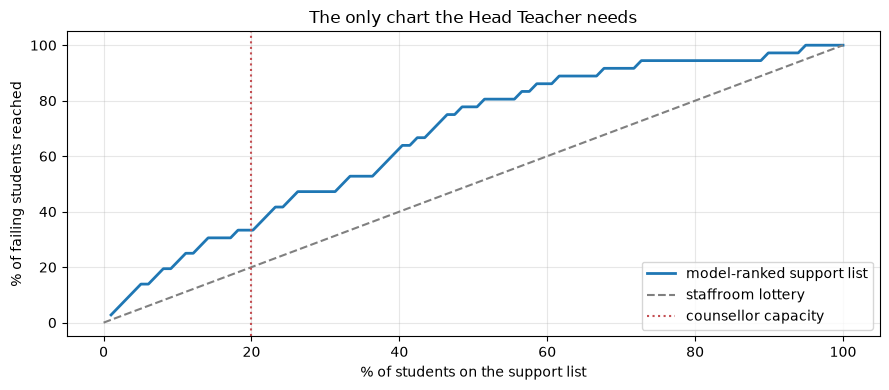

In [7]:
caught = np.cumsum(actually_failed[riskiest_first]) / actually_failed.sum() * 100
listed = np.arange(1, len(y_test) + 1) / len(y_test) * 100

plt.plot(listed, caught, linewidth=2, label="model-ranked support list")
plt.plot([0, 100], [0, 100], "--", color="grey", label="staffroom lottery")
plt.axvline(20, linestyle=":", color="#C44E52", label="counsellor capacity")
plt.xlabel("% of students on the support list")
plt.ylabel("% of failing students reached")
plt.title("The only chart the Head Teacher needs")
plt.legend()
plt.tight_layout()
plt.show()

At the counsellor's real capacity, the model reaches **33% of the students who go
on to fail, against 20% from picking at random.** A lift of about 1.7×.

Is that worth deploying? That is a judgement, and it is yours to make and defend,
not the model's:

- **For:** it is free and uses data the school already holds. The lift is about
  13 percentage points, which across a cohort of 395 students — roughly 130 of
  whom fail — means about **17 additional failing students reached each year**.
- **Against:** 1.7× is a modest lift. Two thirds of the students who fail are
  still missed, and a list with the school's name on it carries a risk of
  becoming a label that follows a child.

The recommendation I would write: **deploy as a ranked suggestion to the
counsellor, never as an automatic assignment, and revisit once attendance data
from the current term is available** — because the model's strongest feature is
last year's absences, and this year's would almost certainly be stronger.

In [8]:
importances = pd.Series(
    model.named_steps["estimate"].feature_importances_,
    index=model.named_steps["prepare"].get_feature_names_out(),
).sort_values(ascending=False)

print("what the model leans on:")
print(importances.head(6).round(3).to_string())

what the model leans on:
numeric__absences     0.184
numeric__failures     0.129
numeric__goout        0.059
numeric__health       0.047
numeric__age          0.046
numeric__studytime    0.038


`absences` and `failures` — prior attendance and prior repeated years. The model
has rediscovered what every experienced teacher already knows, which is both
reassuring and a warning: if the model tells you only what the staffroom already
knew, the gain over current practice may be smaller in the real school than in
this test set.

---

## 6. Error analysis (session 6)

In [9]:
slices = students.loc[X_test.index, ["school", "sex", "address"]].copy()
slices["absolute_error"] = np.abs(y_test.to_numpy() - predicted_grade)
slices["failed"] = actually_failed
slices["on_list"] = 0
slices.iloc[riskiest_first[:int(0.20 * len(y_test))], slices.columns.get_loc("on_list")] = 1

for column in ["school", "address", "sex"]:
    grouped = slices.groupby(column)
    print(pd.DataFrame({
        "students": grouped.size(),
        "MAE": grouped["absolute_error"].mean(),
        "on_list": grouped["on_list"].mean(),
        "caught_of_failing": grouped.apply(
            lambda g: g.loc[g["failed"] == 1, "on_list"].mean() if g["failed"].sum() else np.nan),
    }).round(3).to_string(), "\n")

        students    MAE  on_list  caught_of_failing
school                                             
GP            83  3.082    0.181              0.333
MS            16  2.703    0.250              0.333 

         students    MAE  on_list  caught_of_failing
address                                             
R              26  3.160    0.308              0.417
U              73  2.972    0.151              0.292 

     students    MAE  on_list  caught_of_failing
sex                                             
F          49  3.068    0.245              0.381
M          50  2.976    0.140              0.267 



Error is even across school, address and sex — around 3 grade points everywhere.
**Coverage is not.** Rural students make up 31% of the support list against 15%
of urban students, and female students 25% against 14% of male students. With 99
test students those differences rest on a handful of names, so do not over-read
them — but do not look away from them either.

Two things to say out loud, because this is a project about children.

**`sex` is in this dataset.** Using it as a feature is a policy decision, not a
modelling one — and the charter says protected characteristics need review before
use. Our model includes it; a real deployment would need the school to agree that
explicitly, or drop it.

**Equal error is not equal treatment.** If one group is systematically placed on
the list more often, that needs explaining to the people affected, whatever the
MAE says. Session 6's last table applies: this is a conversation, not a code
change.

---

## 7. Package it (sessions 7 and 9)

In [10]:
ARTIFACT_DIR = ROOT / "app" / "models"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

model.fit(early_features, y)            # refit on everything before saving
joblib.dump(model, ARTIFACT_DIR / "student_support_model.joblib")

data_file = ROOT / "data" / "student-mat.csv"
metadata = {
    "name": "student-support-ranking",
    "version": "0.1.0",
    "trained_at": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"),
    "training_rows": len(students),
    "training_data_md5": hashlib.md5(data_file.read_bytes()).hexdigest()[:12],
    "target": "G3",
    "decision": CHARTER["decision"],
    "capacity": CHARTER["capacity"],
    "excluded_features": ["G1", "G2"],
    "excluded_reason": "not available at the start of the school year",
    "offline_result": "reaches 33% of failing students at 20% capacity (random: 20%)",
    "status": "pilot — suggestion only, never automatic assignment",
}
(ARTIFACT_DIR / "student_support_model.json").write_text(json.dumps(metadata, indent=2))

print(f"saved {(ARTIFACT_DIR / 'student_support_model.joblib').stat().st_size / 1024:.0f} KB")
print(json.dumps(metadata, indent=2)[-420:])

saved 7512 KB
aining_data_md5": "4dc304be95c6",
  "target": "G3",
  "decision": "which ~20% of students get sustained counsellor support",
  "capacity": 0.2,
  "excluded_features": [
    "G1",
    "G2"
  ],
  "excluded_reason": "not available at the start of the school year",
  "offline_result": "reaches 33% of failing students at 20% capacity (random: 20%)",
  "status": "pilot \u2014 suggestion only, never automatic assignment"
}


In [11]:
# The list the counsellor would actually receive.
reloaded = joblib.load(ARTIFACT_DIR / "student_support_model.joblib")
students_scored = students.assign(predicted_grade=reloaded.predict(early_features))

support_list = students_scored.nsmallest(int(CHARTER["capacity"] * len(students)), "predicted_grade")
print(f"support list: {len(support_list)} students\n")
print(support_list[["school", "sex", "age", "absences", "failures", "studytime",
                    "predicted_grade"]].head(8).round(2).to_string())

support list: 79 students

    school sex  age  absences  failures  studytime  predicted_grade
146     GP   F   15         0         3          2             0.30
343     GP   F   17         0         1          2             0.31
137     GP   F   16         0         2          1             0.44
173     GP   F   16         0         3          2             0.62
144     GP   M   17         0         3          1             0.74
160     GP   M   17         0         2          1             0.76
341     GP   M   18         0         1          2             1.01
389     MS   F   18         0         1          2             1.03


That table is the deliverable. Not the MAE, not the feature importances — a list
of names a counsellor can act on in September, with the reasons visible beside
each one.

### Monitoring (session 8)

| Check | Frequency | Alarm |
|-------|-----------|-------|
| Intake distribution against last year | At enrolment | PSI > 0.25 on absences, failures, studytime |
| Support list composition | At publication | Any group's share moves sharply against last year |
| Realised outcomes | End of year | Fewer than 25% of failing students were on the list |
| Model refresh | Yearly | Retrain on the completed cohort |

Note the label delay again: outcomes arrive **once a year**. The model can be
checked properly four times in a four-year secondary programme, which is a strong
argument for keeping a human in the loop rather than automating the decision.

---

## 8. The honest summary

| Phase | What we did | Result |
|-------|-------------|--------|
| Problem framing | Named the decision: 79 support places | Ranking problem, not accuracy problem |
| Data understanding | 395 students, no gaps, 33 columns | Clean data, timing problem |
| Point-in-time audit | Dropped `G1`, `G2` | MAE 1.37 → 3.40; the honest model |
| Baselines | Mean grade, ridge | 3.43, 3.40 — barely distinguishable |
| Model | Random forest | MAE 2.90 |
| Decision metric | Capture at 20% capacity | 33% vs 20% random |
| Error analysis | School, address, sex | Error even; small subgroups; `sex` needs a policy decision |
| Packaging | Pipeline + metadata saved | Reproducible artifact |
| Verdict | **Pilot as a suggestion, not an assignment** | Revisit with current-term attendance |

One sitting, nine steps, and a recommendation the Head Teacher can act on —
including the parts that say "not yet".

---

# Part B — your project

## The brief

Take a problem you care about, run it end to end exactly as part A did, and hand
in something a working team could pick up.

**Your dataset must not be the loan book or the student file.** Use data from your
workplace (with permission), a public source (Kaggle, UCI, data.gov.np, World
Bank, Nepal Rastra Bank), or a dataset you build yourself. It must be **tabular**,
have at least **1,000 rows**, and contain a target you could genuinely act on.

**Choose a problem where a decision changes.** If you cannot name the person whose
work changes because of your model, pick a different problem. That question is
the first thing I will ask, and it is worth 20% of the grade before any modelling
is looked at.

## What to submit

| # | Deliverable | Notes |
|---|-------------|-------|
| 1 | **Project charter**, one page | Session 1's template: decision, owner, decision point, target, baseline, success criteria, guardrails, kill criteria, risks |
| 2 | **Notebook** | The full run: data audit, preparation, features, models, evaluation, error analysis. Narrated, not just code |
| 3 | **Model artifact** | Saved pipeline plus metadata JSON, as in session 9 |
| 4 | **A served model** | A FastAPI endpoint *or* a Streamlit interface. One is enough |
| 5 | **Monitoring plan**, half a page | What you would watch, how often, what would trigger action |
| 6 | **README** | How to install, run, and reproduce your result in under ten minutes |

Submit as a git repository, with a `requirements.txt` that works.

## How it is graded

| Weight | Criterion | What a strong submission shows |
|--------|-----------|-------------------------------|
| **20%** | **Problem framing** | A decision, an owner, a decision point. Success criteria written before modelling. A baseline that is measured, not assumed |
| **20%** | **Data discipline** | Point-in-time audit of every column. Missingness understood, not just filled. Split justified. No leakage — and evidence you went looking |
| **15%** | **Modelling** | Pipeline from raw columns to prediction. Cross-validated comparison with the fold spread reported. Model choice justified against constraints |
| **15%** | **Evaluation** | The right metric for the decision, with an operating point. Cost or capacity reasoning. Error analysis by slice |
| **15%** | **Engineering** | Reproducible, seeded, saved with metadata, served, and it runs from a clean clone |
| **15%** | **Communication and honesty** | A clear recommendation a non-specialist can act on, including limitations and what you would do next |

Note what is **not** on that list: the score itself. A project reporting an honest
AUC of 0.68 with a clear decision and a measured baseline beats one reporting 0.95
with a leaked column, every time. If your first model looks excellent, your first
job is to find out why.

## Suggested timeline

| Week | Work |
|------|------|
| 1 | Choose the problem and the dataset. Write the charter. Get it checked before going further |
| 2 | Data audit, preparation, baselines. Most of the value is in this week |
| 3 | Features, models, cross-validation, metric selection |
| 4 | Error analysis, threshold or operating point, artifact and serving |
| 5 | Monitoring plan, README, rehearse the ten-minute walkthrough |

## Common ways projects lose marks

- **No named decision.** The single biggest one. "Understanding the drivers" is
  not a decision.
- **No baseline.** Without one, no score means anything.
- **A leaked column.** Especially "status" fields, anything with `final_`,
  `resolution_`, `closed_` in the name, and anything suspiciously predictive.
- **Accuracy on imbalanced data.** Session 5 exists entirely because of this.
- **Preprocessing fitted before the split.** Use a pipeline and it cannot happen.
- **A notebook that does not run.** Restart the kernel, run all, before you submit.
- **Burying the recommendation.** Put it at the top, in one paragraph, in words a
  head of department would use.

## Frequently asked

**Can I use deep learning?** Yes, if it beats a well-tuned baseline on your data
and you can justify the cost. On tabular data of this size it usually will not.

**My model is barely better than the baseline.** Then that is your finding. Report
it clearly, show what you tried, and say what data would change the answer. This is
a pass-worthy and often excellent project — see part A of this notebook.

**How big should the notebook be?** Long enough to follow the reasoning, short
enough that someone reads it all. Part A is about the right length for the modelling
narrative.

**Can I work with someone else?** The project is individual, but reviewing each
other's charters in week 1 is encouraged and usually improves both.

---

## If you remember nothing else — from the whole module

**Start from the decision.** A model that changes no decision is a report with
extra steps.

**Measure the cheap option first.** A constant, a rule, a simple model. Most
projects are judged against them and never asked.

**Ask when each value is written.** Point-in-time correctness has saved more
projects than every algorithm in scikit-learn combined.

**Pick the metric before you model, and attach money or capacity to it.** Then
report the operating point, never the metric alone.

**A pipeline makes discipline structural.** Training code and serving code should
be the same code.

**Look at where you are wrong.** Slice analysis has found more value in this
module than every hyperparameter search we ran.

**The world moves.** Monitor inputs, because the labels arrive late — if they
arrive at all.

**Say what you actually found.** Including "this is not ready", "the gain is
modest", and "here is what it would cost to do properly". That honesty is the
whole professional skill; the rest is scikit-learn.

---

## Further reading, if you continue

- Chip Huyen, *Designing Machine Learning Systems* — the closest book to this
  module's point of view.
- Emmanuel Ameisen, *Building Machine Learning Powered Applications* — framing and
  shipping, with worked code.
- Andrew Ng, *Machine Learning Yearning* — free, short, and the best writing on
  error analysis.
- Google, *Rules of Machine Learning* — 43 rules from people who have made every
  mistake in this module at scale.
- Provost and Fawcett, *Data Science for Business* — for the conversations with
  stakeholders that decide whether any of this matters.

---

That is the module. Ten sessions, one loan book, one school, and a habit of
asking what decision changes.

Good luck with your project — bring the charter to week 1 and we will look at it
together.